In [56]:
import pandas as pd 
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import torch
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
df = pd.read_csv('../../IEEE-CIS-Fraud-Detection/Data/04_Encoder/encoder.csv')

In [3]:
đf = df[:70000]

In [4]:
# X: tất cả các cột trừ cột TARGET
X = df.drop("binary_flags__TARGET", axis=1)

# y: cột TARGET
y = df["binary_flags__TARGET"]

In [9]:
# 1. Chia tập data thành bộ train và test với tỉ lệ 80/20 (Giữ nguyên phần chuẩn của bạn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    random_state=42, 
    train_size=0.8, 
    shuffle=True,
    stratify=y 
)

print("--- Trước khi Oversampling ---")
print("Tập Train gốc:", Counter(y_train))
print("Tập Test gốc (GIỮ NGUYÊN, KHÔNG ĐỤNG VÀO):", Counter(y_test))
print("-" * 30)

# THỬ NGHIỆM 1: Thiết lập tỉ lệ thành 50/50
# Ý nghĩa: Số lượng mẫu lớp 1 sẽ được nhân bản lên bằng 100% số lượng lớp 0
ros_5050 = RandomOverSampler(sampling_strategy=1.0, random_state=42)
X_train_res1, y_train_res1 = ros_5050.fit_resample(X_train, y_train)

print("Sau oversampling 50/50 (trên tập Train):", Counter(y_train_res1))


# THỬ NGHIỆM 2: Thiết lập tỉ lệ thành 60/40
# Công thức tính: 40% / 60% = 0.6666... (khoảng 0.67)
# Ý nghĩa: Số lượng lớp 1 sau khi tăng sẽ bằng ~67% số lượng lớp 0
ros_6040 = RandomOverSampler(sampling_strategy=0.667, random_state=42)
X_train_res2, y_train_res2 = ros_6040.fit_resample(X_train, y_train)

print("Sau oversampling 60/40 (trên tập Train):", Counter(y_train_res2))


# THỬ NGHIỆM 3: Thiết lập tỉ lệ thành 70/30
# Công thức tính: 30% / 70% = 0.4285... (khoảng 0.429)
# Ý nghĩa: Số lượng lớp 1 sau khi tăng sẽ bằng ~42.9% số lượng lớp 0
ros_7030 = RandomOverSampler(sampling_strategy=0.429, random_state=42)
X_train_res3, y_train_res3 = ros_7030.fit_resample(X_train, y_train)

print("Sau oversampling 70/30 (trên tập Train):", Counter(y_train_res3))

--- Trước khi Oversampling ---
Tập Train gốc: Counter({0: 81263, 1: 19853})
Tập Test gốc (GIỮ NGUYÊN, KHÔNG ĐỤNG VÀO): Counter({0: 20316, 1: 4963})
------------------------------
Sau oversampling 50/50 (trên tập Train): Counter({1: 81263, 0: 81263})
Sau oversampling 60/40 (trên tập Train): Counter({0: 81263, 1: 54202})
Sau oversampling 70/30 (trên tập Train): Counter({0: 81263, 1: 34861})


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

***
### Tỉ lệ giữ nguyên không thay đổi 

In [53]:
# clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
# models, predictions = clf.fit(X_train, X_test, y_train, y_test)
# # Xuất bảng kết quả đánh giá các model
# print(models)

***
### Test khả năng dự đoán của model lên các kiểu oversampling

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import xgboost as xgb 

***
### Tỉ lệ 50 / 50

In [55]:
dt_model = DecisionTreeClassifier(
    criterion='gini',   # hoặc 'entropy'
    max_depth=None,     # độ sâu tối đa của cây
    random_state=42     # để tái lập kết quả
)

rf_model = RandomForestClassifier(
    n_estimators=200,   # số lượng cây trong rừng
    criterion='gini',   # hoặc 'entropy'
    max_depth=None,
    random_state=42,
    n_jobs=-1           # tận dụng đa luồng
)
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

# Khởi tạo BaggingClassifier (Mặc định dùng DecisionTree làm base estimator)
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)



Decision Tree Accuracy: 0.8820364729617469
Random Forest Accuracy: 0.9287155346334902
XGBoost Accuracy: 0.9097670002769097
Bagging Accuracy: 0.9340954942837929


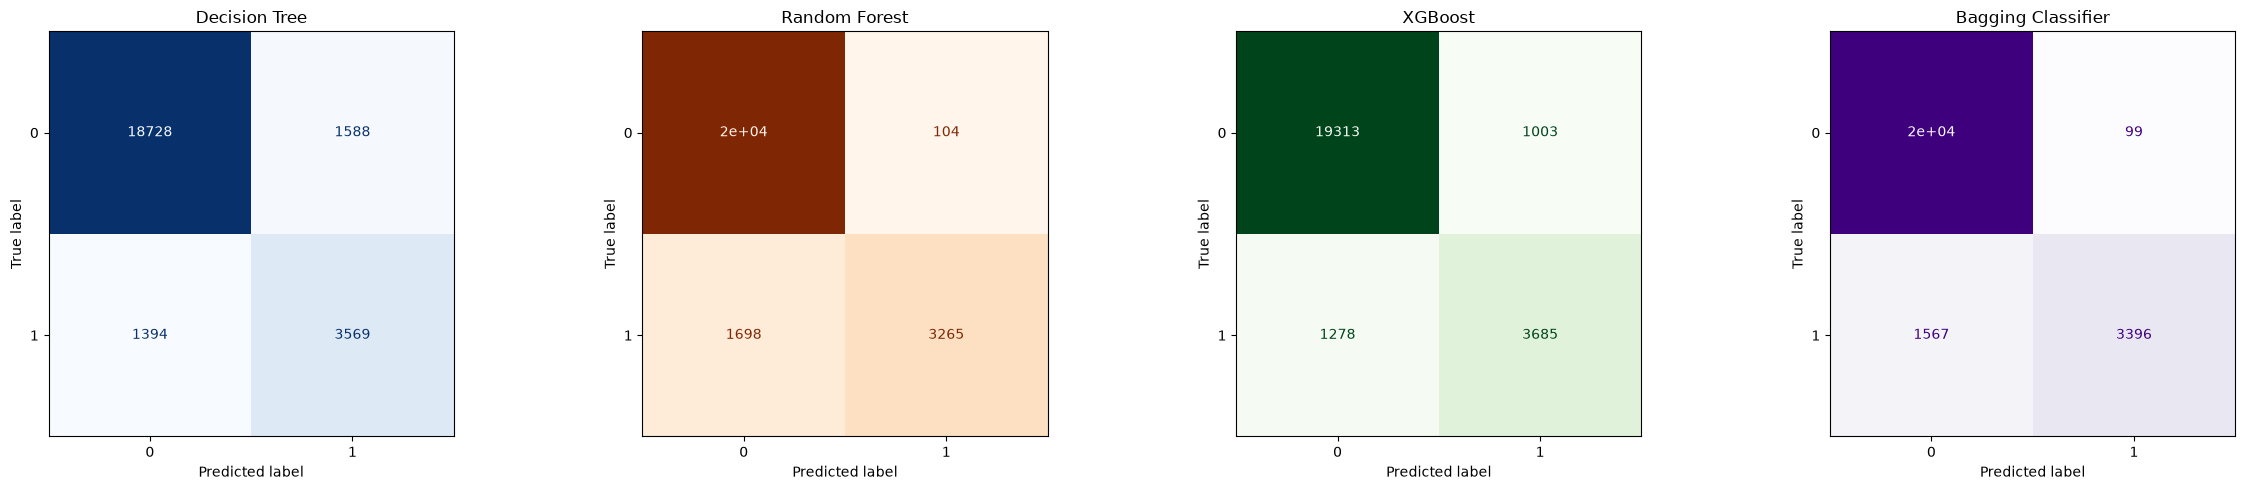

=== Decision Tree Report ===
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     20316
           1       0.69      0.72      0.71      4963

    accuracy                           0.88     25279
   macro avg       0.81      0.82      0.82     25279
weighted avg       0.88      0.88      0.88     25279

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     20316
           1       0.97      0.66      0.78      4963

    accuracy                           0.93     25279
   macro avg       0.95      0.83      0.87     25279
weighted avg       0.93      0.93      0.92     25279

=== XGBoost Report ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94     20316
           1       0.79      0.74      0.76      4963

    accuracy                           0.91     25279
   macro avg       0.86      0.85      0.85    

In [57]:
# ==========================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
# (Giả định dt_model, rf_model, xgb_model đã được khai báo ở trên)



# Huấn luyện mô hình trên tập oversample (res1)
dt_model.fit(X_train_res1, y_train_res1)
rf_model.fit(X_train_res1, y_train_res1)
xgb_model.fit(X_train_res1, y_train_res1)
bagging_model.fit(X_train_res1, y_train_res1)  # <--- FIT BAGGING

# ==========================================
# 2. DỰ ĐOÁN
# ==========================================
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_bagging = bagging_model.predict(X_test)  # <--- PREDICT BAGGING

# ==========================================
# 3. ĐÁNH GIÁ ACCURACY
# ==========================================
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))  # <--- IN ACCURACY BAGGING

# ==========================================
# 4. TẠO VÀ VẼ CONFUSION MATRIX (4 SUBPLOTS)
# ==========================================
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)  # <--- CM BAGGING

# Tạo figure với 4 subplot song song
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Decision Tree
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False)
axes[0].set_title("Decision Tree")

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Oranges, ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap=plt.cm.Greens, ax=axes[2], colorbar=False)
axes[2].set_title("XGBoost")

# Bagging Classifier
disp_bagging = ConfusionMatrixDisplay(confusion_matrix=cm_bagging)
disp_bagging.plot(cmap=plt.cm.Purples, ax=axes[3], colorbar=False)  # Sử dụng màu Tím (Purples)
axes[3].set_title("Bagging Classifier")

plt.tight_layout()
plt.show()

# ==========================================
# 5. IN CLASSIFICATION REPORT
# ==========================================
print("=== Decision Tree Report ===")
print(classification_report(y_test, y_pred_dt))

print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

print("=== XGBoost Report ===")
print(classification_report(y_test, y_pred_xgb))

print("=== Bagging Classifier Report ===")  # <--- REPORT BAGGING
print(classification_report(y_test, y_pred_bagging))

***
### Tỉ lệ 60 / 40

Decision Tree Accuracy: 0.8806914830491712
Random Forest Accuracy: 0.9288342102140116
xgb_model Accuracy: 0.9237707187784326


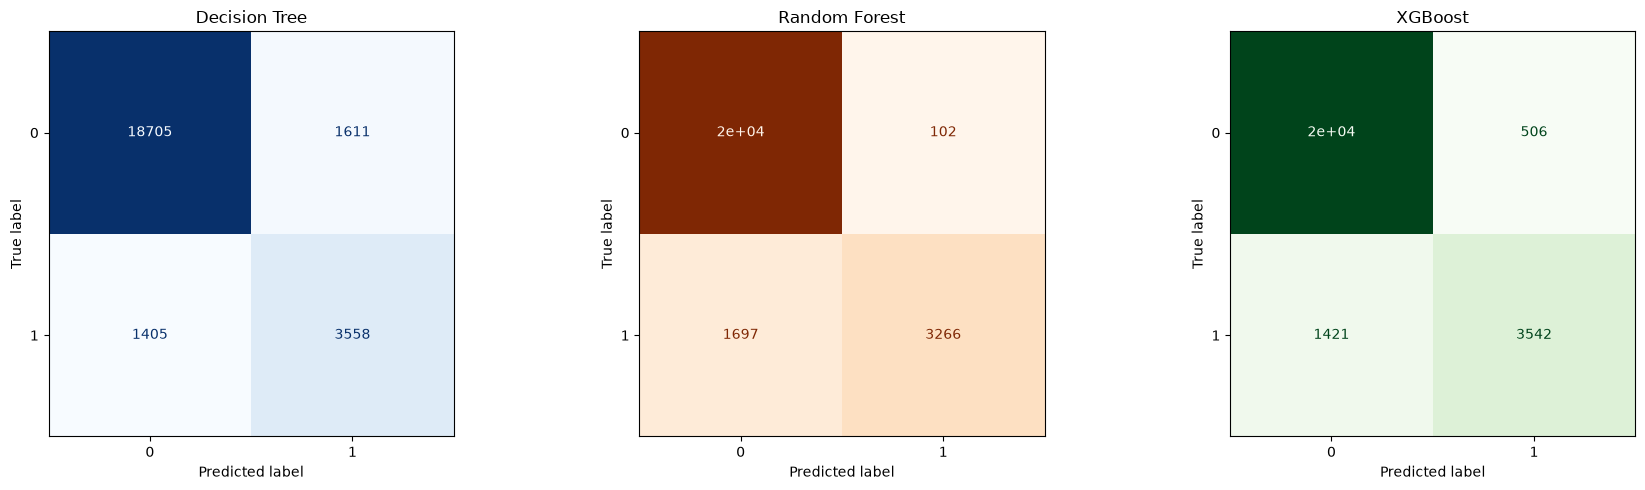

=== Decision Tree Report ===
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     20316
           1       0.69      0.72      0.70      4963

    accuracy                           0.88     25279
   macro avg       0.81      0.82      0.81     25279
weighted avg       0.88      0.88      0.88     25279

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     20316
           1       0.97      0.66      0.78      4963

    accuracy                           0.93     25279
   macro avg       0.95      0.83      0.87     25279
weighted avg       0.93      0.93      0.92     25279

=== XGBoost Report ===
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     20316
           1       0.88      0.71      0.79      4963

    accuracy                           0.92     25279
   macro avg       0.90      0.84      0.87    

In [39]:
# Khởi tạo mô hình


# Huấn luyện mô hình
dt_model.fit(X_train_res2, y_train_res2)
rf_model.fit(X_train_res2, y_train_res2)
xgb_model.fit(X_train_res2, y_train_res2)

# Dự đoán
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
# Đánh giá
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("xgb_model Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Tạo confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Tạo figure với 3 subplot song song
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False)
axes[0].set_title("Decision Tree")

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Oranges, ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap=plt.cm.Greens, ax=axes[2], colorbar=False)
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()


from sklearn.metrics import classification_report
# Decision Tree report
print("=== Decision Tree Report ===")
print(classification_report(y_test, y_pred_dt))

# Random Forest report
print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

# XGBoost report
print("=== XGBoost Report ===")
print(classification_report(y_test, y_pred_xgb))

***
### Tỉ lệ 70 / 30

Decision Tree Accuracy (Threshold 0.25): 0.8851220380553029
Random Forest Accuracy (Threshold 0.25): 0.8547806479686696
XGBoost Accuracy (Threshold 0.25): 0.8870604058704854


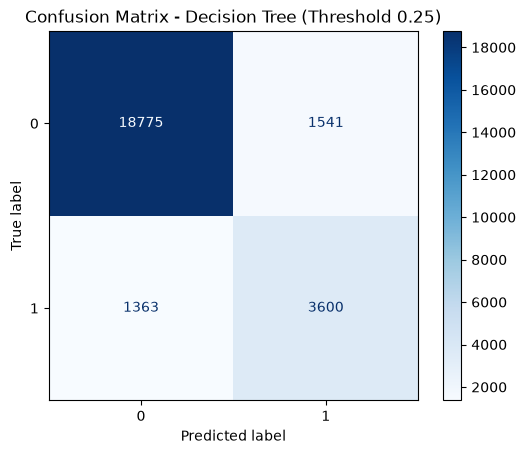

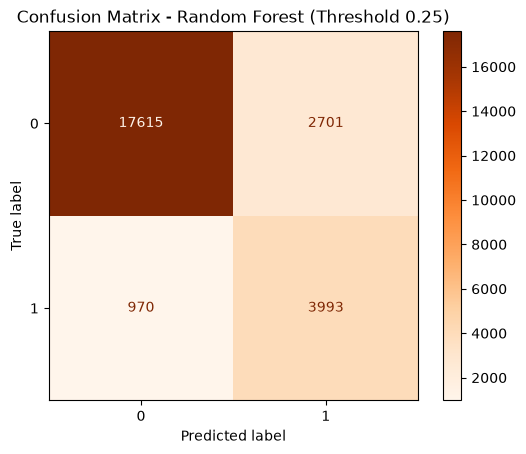

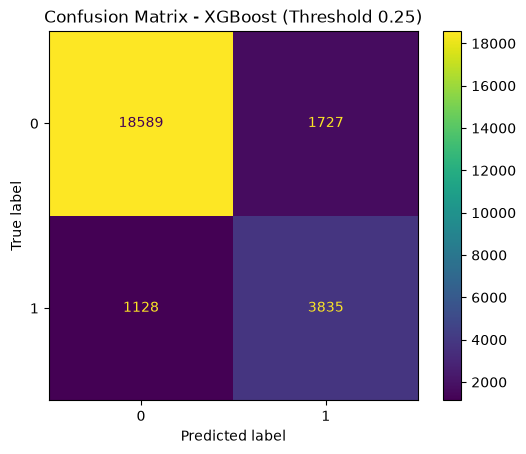

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb  # <--- THÊM THƯ VIỆN XGBOOST
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# --- NGƯỠNG PHÂN LOẠI MỚI (TỰ ĐỊNH NGHĨA) ---
CUSTOM_THRESHOLD = 0.25 

# Khởi tạo mô hình XGBoost (nếu bạn chưa khởi tạo ở trên)
# Lưu ý: Vì bạn đã dùng dữ liệu oversample (res3), ta không cần dùng scale_pos_weight ở đây nữa
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

# 1. Huấn luyện mô hình
dt_model.fit(X_train_res3, y_train_res3)
rf_model.fit(X_train_res3, y_train_res3)
xgb_model.fit(X_train_res3, y_train_res3)  # <--- HẤN LUYỆN XGBOOST

# 2. Dự đoán xác suất thay vì dự đoán nhãn trực tiếp
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]  # <--- LẤY XÁC SUẤT CỦA XGBOOST

# 3. Ép nhãn dựa trên ngưỡng phân loại mới (CUSTOM_THRESHOLD)
y_pred_dt = (y_proba_dt >= CUSTOM_THRESHOLD).astype(int)
y_pred_rf = (y_proba_rf >= CUSTOM_THRESHOLD).astype(int)
y_pred_xgb = (y_proba_xgb >= CUSTOM_THRESHOLD).astype(int)  # <--- ÁP NGƯỠNG CHO XGBOOST

# --- ĐÁNH GIÁ MÔ HÌNH ---

# In Accuracy
print(f"Decision Tree Accuracy (Threshold {CUSTOM_THRESHOLD}):", accuracy_score(y_test, y_pred_dt))
print(f"Random Forest Accuracy (Threshold {CUSTOM_THRESHOLD}):", accuracy_score(y_test, y_pred_rf))
print(f"XGBoost Accuracy (Threshold {CUSTOM_THRESHOLD}):", accuracy_score(y_test, y_pred_xgb))  # <--- IN ACCURACY XGBOOST

# Vẽ Confusion Matrix cho Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Decision Tree (Threshold {CUSTOM_THRESHOLD})")
plt.show()

# Vẽ Confusion Matrix cho Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Oranges)
plt.title(f"Confusion Matrix - Random Forest (Threshold {CUSTOM_THRESHOLD})")
plt.show()

# Vẽ Confusion Matrix cho XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap=plt.cm.viridis)  # Sử dụng màu Viridis (Xanh lá - Vàng) để phân biệt
plt.title(f"Confusion Matrix - XGBoost (Threshold {CUSTOM_THRESHOLD})")
plt.show()

### 📐 Công thức và Số liệu tính Tỷ lệ sai (Error Rate) theo 3 Nhóm Dữ liệu

---

#### 1. Công thức tổng quát

* **Tỷ lệ sai nhóm 0 (FPR - Đoán nhầm người tốt):**
  $$\text{FPR} = \frac{\text{FP}}{\text{TN} + \text{FP}} = \frac{\text{FP}}{20,316} \times 100\%$$

* **Tỷ lệ sai nhóm 1 (FNR - Bỏ sót ca vỡ nợ):**
  $$\text{FNR} = \frac{\text{FN}}{\text{TP} + \text{FN}} = \frac{\text{FN}}{4,963} \times 100\%$$

---

#### 2. Nhóm 1: Tỷ lệ dữ liệu 50/50 (Hình 1)

* **Decision Tree:**
  * $\text{FPR} = \frac{1588}{20316} \approx \mathbf{7.82\%}$
  * $\text{FNR} = \frac{1394}{4963} \approx \mathbf{28.09\%}$

* **Random Forest:**
  * $\text{FPR} = \frac{104}{20316} \approx \mathbf{0.51\%}$
  * $\text{FNR} = \frac{1698}{4963} \approx \mathbf{34.21\%}$

* **XGBoost:**
  * $\text{FPR} = \frac{1003}{20316} \approx \mathbf{4.94\%}$
  * $\text{FNR} = \frac{1278}{4963} \approx \mathbf{25.75\%}$

---

#### 3. Nhóm 2: Tỷ lệ dữ liệu 60/40 (Hình 2)

* **Decision Tree:**
  * $\text{FPR} = \frac{1611}{20316} \approx \mathbf{7.93\%}$
  * $\text{FNR} = \frac{1405}{4963} \approx \mathbf{28.31\%}$

* **Random Forest:**
  * $\text{FPR} = \frac{102}{20316} \approx \mathbf{0.50\%}$
  * $\text{FNR} = \frac{1697}{4963} \approx \mathbf{34.19\%}$

* **XGBoost:**
  * $\text{FPR} = \frac{506}{20316} \approx \mathbf{2.49\%}$
  * $\text{FNR} = \frac{1421}{4963} \approx \mathbf{28.63\%}$

---

#### 4. Nhóm 3: Tỷ lệ dữ liệu 70/30 (Hình 3)

* **Decision Tree:**
  * $\text{FPR} = \frac{1541}{20316} \approx \mathbf{7.58\%}$
  * $\text{FNR} = \frac{1363}{4963} \approx \mathbf{27.46\%}$

* **Random Forest:**
  * $\text{FPR} = \frac{77}{20316} \approx \mathbf{0.38\%}$
  * $\text{FNR} = \frac{1726}{4963} \approx \mathbf{34.78\%}$

* **XGBoost:**
  * $\text{FPR} = \frac{236}{20316} \approx \mathbf{1.16\%}$
  * $\text{FNR} = \frac{1490}{4963} \approx \mathbf{30.02\%}$

***
# *Thực hiện bước huấn luyện model*
***

In [ ]:
# Phần chia x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = X_train_res1, X_test, y_train_res1, y_test

